In [12]:
from py_compile import main
import numpy as np
import jax.numpy as jnp
import capytaine as cpt
from capytaine.io.meshio import load_from_meshio
import matplotlib.pyplot as plt
from scipy.optimize import brute
import pygmsh
import gmsh
from scipy.linalg import block_diag
import xarray as xr
import jax
import os
 
# Custom libraries
import wecopttool as wot
from multibody import MbdSystem, linearize_mbd
from multibody.linearization.linearization_main import LinearizationManager
from multibody.linearization.hydro_linear_mckf import HydroLinearMCKF

# Import examples variables
import m4e_inputs_oneFlap as ex
#from hydro_inputs import waves, freq, platform, flap1, flap2

## set colorblind-friendly colormap for plots
plt.style.use('tableau-colorblind10')

import logging
logging.getLogger().setLevel(logging.INFO)

In [13]:
wavefreq = 1/8 # Hz
f1 = wavefreq
nfreq = 10

freq = wot.frequency(f1, nfreq, False) # False -> no zero frequency

amplitude = 0.01/2 # m
phase = 0 # degrees
wavedir = 0 # degrees

waves = wot.waves.regular_wave(f1, nfreq, wavefreq, amplitude, phase, wavedir)

INFO:capytaine.io.meshio:Stored 312 triangle faces as quadrilaterals


INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_9"), lid_mesh=None, dofs={}, center_of_mass=[ 0.    0.   -0.36], name="flap").
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="flap").rotation_center = [0, 0, -0.36]
INFO:capytaine.bodies.bodies:Clipping flap with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])


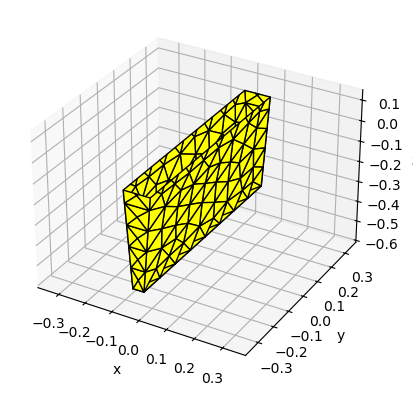

In [14]:
# platform is a rectangle with cg at -0.46 and 1.44 m long, 0.76 m wide
flapThicknessBottom = 0.04
flapThicknessTop = 0.1
flapWidth = 0.76
flapHeight = 0.5
flapCG = [0, 0, -0.36] # from water surface/origin

with pygmsh.geo.Geometry() as geom:
    flap = geom.add_polygon(
            [[-flapThicknessBottom/2, -flapWidth/2, -0.46],
            [flapThicknessBottom/2, -flapWidth/2, -0.46],
            [flapThicknessTop/2, -flapWidth/2, -0.46+flapHeight],
            [-flapThicknessTop/2, -flapWidth/2, -0.46+flapHeight]],mesh_size=0.1)
    geom.extrude(flap,[0,flapWidth,0])
    flapMesh = geom.generate_mesh()

# define the floating body
flap = cpt.FloatingBody(mesh=flapMesh, name=f'flap', center_of_mass=flapCG)
flap.rotation_center = flapCG # define rotation about cg and M4E will handle transformaiton
flap.add_translation_dof(name='Surge')
flap.add_translation_dof(name='Heave')
flap.add_rotation_dof(name='Pitch')
flap = flap.immersed_part()
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([0.5*(.05*.76*.56)*1000,0.5*(.05*.76*.56)*1000,1.19]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(flap.dofs),
                                    'radiating_dof': list(flap.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
flap.inertia_matrix = rigid_inertia_matrix_xr
flap.hydrostatic_stiffness = flap.compute_hydrostatic_stiffness(rho=1025)

flap.show_matplotlib()
#flap.show()


In [15]:
#%% Load or run BEM
fname = 'bem_oneFlap.nc'
if os.path.exists(fname):
    bem_data = wot.read_netcdf(fname)
else:
    bem_data = wot.run_bem(flap, freq, wave_dirs=0)
    bem_data['radiating_dof'] = bem_data['radiating_dof'].astype(str)
    bem_data['influenced_dof'] = bem_data['influenced_dof'].astype(str)
    wot.write_netcdf(fname, bem_data)

INFO:capytaine.green_functions.delhommeau:Loading tabulation from C:\Users\jtgrasb\AppData\Local\capytaine\Cache\2.3.1\tabulation_float64_scaled_nemoh3_676_100.0_372_-251.0_1001.npz


[14:15:21] WARNING  center_of_mass already defined as [ 0.    0.   -0.36].

           WARNING  rotation_center already defined as [0, 0, -0.36].

INFO:capytaine.bodies.bodies:Clipping copy_of_flap with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_9 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.


Output()

...

INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=3.927, water_depth=inf, radiating_dof='Surge', rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=3.927, water_depth=inf, radiating_dof='Heave', rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=3.927, water_depth=inf, radiating_dof='Pitch', rho=1025.0).
INFO:capytaine.bem.solver:Solve DiffractionProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=4.712, water_depth=inf, wave_direction=0.000, rho=1025.0).


INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=4.712, water_depth=inf, radiating_dof='Surge', rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=4.712, water_depth=inf, radiating_dof='Heave', rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=4.712, water_depth=inf, radiating_dof='Pitch', rho=1025.0).
INFO:capytaine.bem.solver:Solve DiffractionProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=5.498, water_depth=inf, wave_direction=0.000, rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=5.498, water_depth=inf, radiating_dof='Surge', rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=5.498, water_depth=inf, radiating_dof='Heave'

INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=6.283, water_depth=inf, radiating_dof='Surge', rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=6.283, water_depth=inf, radiating_dof='Heave', rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=6.283, water_depth=inf, radiating_dof='Pitch', rho=1025.0).
INFO:capytaine.bem.solver:Solve DiffractionProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=7.069, water_depth=inf, wave_direction=0.000, rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=7.069, water_depth=inf, radiating_dof='Surge', rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=7.069, water_depth=inf, radiating_dof='Heave'

INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=7.854, water_depth=inf, radiating_dof='Surge', rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=7.854, water_depth=inf, radiating_dof='Heave', rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=7.854, water_depth=inf, radiating_dof='Pitch', rho=1025.0).


INFO:capytaine.bem.solver:Solver timer summary:
                  total  nb_calls   mean
task                                    
Solve total       0.711        40  0.018
  Green function  0.288        40  0.007
  Linear solver   0.230        40  0.006


In [16]:
print(bem_data['added_mass'])

<xarray.DataArray 'added_mass' (omega: 10, radiating_dof: 3, influenced_dof: 3)> Size: 720B
array([[[ 1.53375082e+02,  3.73537597e-03,  2.43073564e+01],
        [ 1.96370865e-02,  3.70183049e+00, -2.86169681e-04],
        [ 2.42531693e+01, -3.83718631e-03,  5.03359389e+00]],

       [[ 1.57348365e+02,  3.39860845e-03,  2.50924059e+01],
        [ 1.99453826e-02,  3.73990561e+00, -3.23373084e-04],
        [ 2.50387273e+01, -4.00715100e-03,  5.19078079e+00]],

       [[ 1.65708729e+02,  2.86142225e-03,  2.67317133e+01],
        [ 2.06856867e-02,  3.49965835e+00, -1.45924296e-04],
        [ 2.66791504e+01, -3.86274599e-03,  5.51605644e+00]],

       [[ 1.80863170e+02,  2.17332495e-03,  2.97307602e+01],
        [ 2.21109005e-02,  3.04261780e+00,  3.28620269e-04],
        [ 2.96804229e+01, -3.43822121e-03,  6.11423598e+00]],

       [[ 2.03157984e+02,  1.34948189e-03,  3.43346910e+01],
        [ 2.40068850e-02,  2.53546972e+00,  1.01945676e-03],
        [ 3.42874942e+01, -2.97447358e-03,  7.

In [17]:
########################################
# Define the multibody system
MBDsys      = MbdSystem.from_example(ex)
mainNumVars = MBDsys.ic # For now

#%% Linearization
# Define the equilibrium position
q0 = mainNumVars[:len(MBDsys.Q)]

# Obtain the mass and inertia values from all_bodies
mass_and_inertia = np.diag(flap.inertia_matrix.values)
m0 = mass_and_inertia[::3]
J0 = mass_and_inertia[2::3]
ex.m0 = m0 # Updating it here just in case
ex.J0 = J0

# Instantiate the linearized MBD system
LinManager = LinearizationManager(MBDsys, q0, mainNumVars, m0, J0)

# Instanciate and register hydrodynamics adapter
hydroAdapter = HydroLinearMCKF(
        MBDsys,
        (mainNumVars, ex.m0, ex.J0),
        is_2D=True,
        data=bem_data
        )

LinManager.register(hydroAdapter)

# Instantiate the total linearized system with attributes M,C,K,F
LinSystem = LinManager.linearize_total(mainNumVars)

# print('Total linearized mass matrix in joint coordinates:')
# print(LinSystem.M)
# print('Total linearized damping matrix in joint coordinates:')
# print(LinSystem.C)
# print('Total linearized stiffness matrix in joint coordinates:')
# print(LinSystem.K)
# print('Total linearized force vector in joint coordinates:')
# print(LinSystem.F)
# TODO: convert from unit force (capytaine coefficient) to excitation force
# whenever we integrate manually. WecOptTool does it internally.


Problem initialization finished in:		 0.001 seconds
All branches in the graph:
R and RD matrices calculation finished in:	 0.030 seconds
Symbolic EOM computation finished in:		 0.001 seconds
Compiling EOM expressions finished in:		 0.048 seconds


In [18]:
#from multibody.linearization.linearize_eom import linearize_mbd  # type: ignore
R = MBDsys.R_func(*mainNumVars)
#print(mainNumVars)
print(R)

#linMBD = linearize_mbd(MBDsys, q0, m0, J0)
for name, ad in LinManager.adapters.items():
    M, C, K, F = ad.linearized_MCKF(mainNumVars)
    Mh = R.T[None, :, :] @ M @ R[None, :, :] 

print(bem_data['added_mass'])
print(Mh)

[[ 0.13930058]
 [-0.01397668]
 [ 1.        ]]
<xarray.DataArray 'added_mass' (omega: 10, radiating_dof: 3, influenced_dof: 3)> Size: 720B
array([[[ 1.53375082e+02,  3.73537597e-03,  2.43073564e+01],
        [ 1.96370865e-02,  3.70183049e+00, -2.86169681e-04],
        [ 2.42531693e+01, -3.83718631e-03,  5.03359389e+00]],

       [[ 1.57348365e+02,  3.39860845e-03,  2.50924059e+01],
        [ 1.99453826e-02,  3.73990561e+00, -3.23373084e-04],
        [ 2.50387273e+01, -4.00715100e-03,  5.19078079e+00]],

       [[ 1.65708729e+02,  2.86142225e-03,  2.67317133e+01],
        [ 2.06856867e-02,  3.49965835e+00, -1.45924296e-04],
        [ 2.66791504e+01, -3.86274599e-03,  5.51605644e+00]],

       [[ 1.80863170e+02,  2.17332495e-03,  2.97307602e+01],
        [ 2.21109005e-02,  3.04261780e+00,  3.28620269e-04],
        [ 2.96804229e+01, -3.43822121e-03,  6.11423598e+00]],

       [[ 2.03157984e+02,  1.34948189e-03,  3.43346910e+01],
        [ 2.40068850e-02,  2.53546972e+00,  1.01945676e-03],


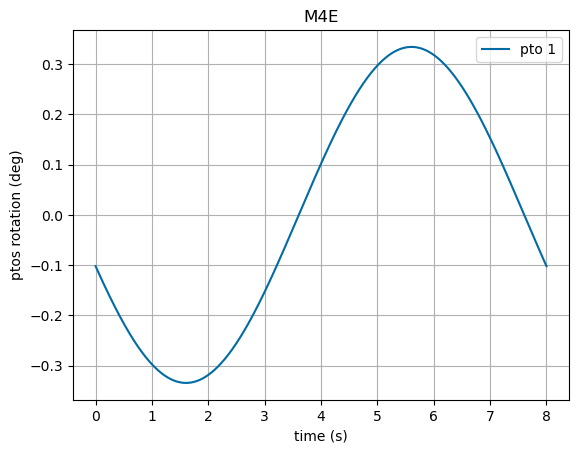

INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [5.56e-02, nan, 0.00e+00]
INFO:wecopttool.core:Optimization terminated successfully    (Exit mode 0)
c:\Users\jtgrasb\AppData\Local\anaconda3\envs\wot_dev\Lib\site-packages\wecopttool\core.py:967: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'omega' ('omega',) The recommendation is to set join explicitly for this case.
  results_fd = xr.merge([fd_state, fd_forces, wave])
c:\Users\jtgrasb\AppData\Local\anaconda3\envs\wot_dev\Lib\site-packages\wecopttool\core.py:967: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. 

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.0
            Iterations: 1
            Function evaluations: 2
            Gradient evaluations: 1


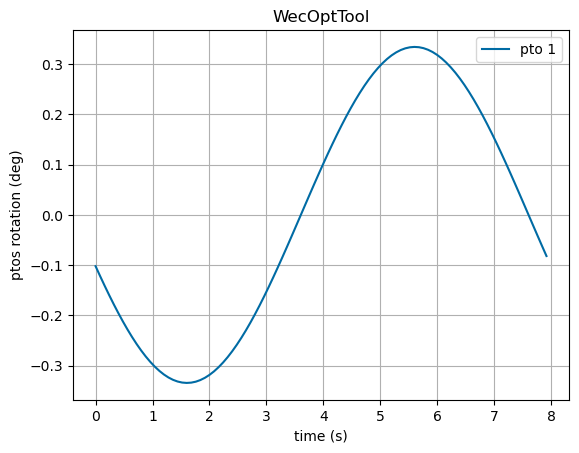

In [19]:
#%% Define the impedance matrix
# Define the excitation omegas
omega = freq*2*np.pi

# Extract linearized matrices
M = LinSystem.M
C = LinSystem.C
K = LinSystem.K
#K[0] = 71.48
F = LinSystem.F

# Impedance matrix in joint coordinates
impedance_reduced = M * (1j * omega[:, None, None]) + C - 1j * K[None, :, :] * (1/omega)[:, None, None]

# Convert excitation force to xarray
wave_direction = waves.wave_direction.values
nwave_direction = len(wave_direction)
coords_exc = {
    'omega': (['omega'], omega, {'units': 'rad/s'}),
    'wave_direction': (['wave_direction'], wave_direction, {'units': 'rad'}),
    'influenced_dof': (['influenced_dof'], ['pitch_flap'], {}),
}

excitation_reduced = xr.DataArray(F.transpose(0,2,1), coords=coords_exc, attrs={})

#%% Additional forces
# transformation variables
dxdq0   = LinManager.dxdq0_func(*mainNumVars) # Since we don't have symbolic variables, the input should not matter
R0      = LinManager.R0

# add forces to stabilize system
#mooring_stiffness = np.diag([3*1e5, 6e4, 5e4, 0, 0, 0, 0, 0, 0])
#mooring_stiffness = R0.T @ mooring_stiffness @ dxdq0

#mooring_damping = np.diag([3*1e4, 5e4, 5e5, 0, 0, 0, 0, 0, 0])
#mooring_damping = R0.T @ mooring_damping @ R0


#########################################
# Solve using frequency domain
Fexc = F * waves.values 
Cnew = C # + mooring_damping[None, :, :]
Knew = K # + mooring_stiffness
Z = Knew - M[0]* (omega[0]**2) + Cnew[0] * 1j * omega[0]
qinf = np.linalg.solve(Z, Fexc[0])

# Test for the first frequency
q0 = qinf
q0_norm = np.abs(q0)
phase = np.angle(q0)


t_array = np.linspace(0, 8, 1000)
q0_t = q0_norm * np.cos(omega[0]*t_array + phase)
q0_t_deg = q0_t[0:1] * 180/np.pi

plt.figure()
plt.plot(t_array, q0_t_deg[0])
#plt.plot(t_array, q0_t_deg[2])
plt.xlabel('time (s)')
plt.ylabel('ptos rotation (deg)')
plt.legend(['pto 1'])
plt.title('M4E')
plt.grid()
plt.show()


#########################################
# Solve using wec opt tool

def f_mooring(wec, x_wec, x_opt, wave, nsubsteps=1):
    pos = wec.vec_to_dofmat(x_wec)
    vel = jnp.dot(wec.derivative_mat,pos)
 
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)
    mooring = -pos @ mooring_stiffness - vel @ mooring_damping
    print(np.shape(mooring))
    #print(mooring)
    mooring_force = jnp.dot(time_matrix,mooring)
    #print(mooring_force)
    return mooring_force

# WecOptTool does not take gravity into account and assumes equilibrium so no pretension needed

f_add = {} #{'mooring': f_mooring}

#%% Define and solve the WOT object
wec = wot.WEC.from_impedance(
    freq,
    impedance=impedance_reduced,
    exc_coeff=excitation_reduced,
    hydrostatic_stiffness=K,
    constraints=None,
    f_add=f_add,
)

# Objective function
obj_fun = lambda wec, x_wec, x_opt, waves : 0
nstate_opt = 0

# Solve
scale_x_wec = 1e1
scale_x_opt = 1e-3
scale_obj = 1e-2

results = wec.solve(
    waves,
    obj_fun,
    nstate_opt,
    scale_x_wec=scale_x_wec,
    scale_x_opt=scale_x_opt,
    scale_obj=scale_obj,
)

#%% Plot results
nsubsteps = 5
wec_fdom, wec_tdom = wec.post_process(wec, results, waves, nsubsteps=nsubsteps)
# wec_tdom['wave_elev'].plot()

# plt.figure()
# plt.plot(wec_tdom['time'],wec_tdom.pos[0,0,:])
# plt.plot(wec_tdom['time'],wec_tdom.pos[0,1,:])
# plt.plot(wec_tdom['time'],wec_tdom.pos[0,2,:]*180/np.pi)
# plt.xlabel('time (s)')
# plt.ylabel('platform position (m or deg)')
# plt.legend(['surge','heave','pitch'])
# plt.grid()


plt.figure()
plt.plot(wec_tdom['time'],wec_tdom.pos[0,0,:]*180/np.pi)
#plt.plot(wec_tdom['time'],wec_tdom.pos[0,0,:]*180/np.pi)
plt.xlabel('time (s)')
plt.ylabel('ptos rotation (deg)')
plt.legend(['pto 1'])
plt.title('WecOptTool')
plt.grid()
plt.show()